# Семинар 5,6 - Описательные статистики. Пропуски и выбросы

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/aaparshina/FCI_22-23_data_analysis/main/data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Таблицы с описательными статистиками**

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


Общая описательная таблица

In [ ]:
df.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## **Меры центральной тенденции**

**Мера центральной тенденции** - такое значение, которое находится в центре распределения и наилучшим способом описывает *типичное* наблюдение из данных

### Среднее арифметическое `.mean()`

**Среднее арифметическое** - число, равное сумме всех чисел выборки или генеральной совокупности, деленной на их количество

+ Не устойчива к выбросам (экстремальным значениям)
+ Рассчитывается для количественных данных

$$
\bar {x} =  \frac {1}{n} \sum _{i=1}^{n}x_{i}
$$

ПРИМЕР:

Выборка/Генеральная совокупность: 1 3 5 6

Среднее арифметическое: (1+3+5+6)/4 = 3,75


In [ ]:
df['Age'].mean()

29.69911764705882

### Медиана `.median()`

**Медиана** - это точка ниже и выше которой находится ровно по 50% значений в распределении

+ Устойчива к выбросам (экстремальным значениям)
+ Рассчитывается для количественных данных

In [ ]:
df['Age'].median()

28.0

ПРИМЕР (четное количество элементов):

Выборка 1 5 3 6

Поиск медианы:

1. Упорядочим значения: 1 **3 5** 6
2. Найдем среднее значений по середине: (3+5)/2=4
3. 4 это медиана

ПРИМЕР (нечетное кол-во элементов):

Выборка 1 5 3 6 2

Поиск медианы:

1. Упорядочим значения: 1 2 **3** 5 6

2. Найдем значение ровно по середине: 3

3. 3 это медиана

### Мода. `.mode()`

**Мода** — это значение переменной с самой большой частотой, т.е. самое популярное значение переменной

+ Рассчитывается для количественных и категориальных данных

In [ ]:
df['Pclass'].mode()

,Pclass
0,3


ПРИМЕР:

Выборка 1 2 2 3 5 5 5 4

Поиск моды:

1. Строим таблицу частотности:

**1** - 1

**2** - 2

**3** - 1

**4** - 1

**5** - 3


2. Чаще всего встречается число 5

3. 5 это мода



ПРИМЕР:

Выборка 1 2 2 2 3 5 5 5 4

Поиск моды:

1. Строим таблицу частотности:

**1** - 1

**2** - 3

**3** - 1

**4** - 1

**5** - 3


2. Чаще всего встречается число 5 и 2

3. 2 и 5 это мода

## A2 (1)

На рисунке ниже изображена гистограмма некоторой переменной. Выберите **неверное утверждение.**

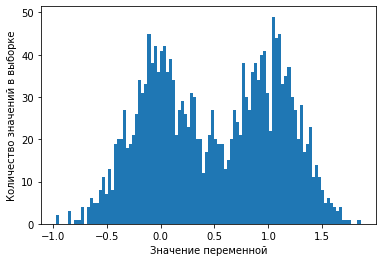

 - Медиана переменной равна 0.


- Значения переменной взяты из разных выборок.


- Переменная может являться непрерывной.


- Ряд значений переменной содержит не менее одной моды.

## A2 (2)

Дана выборкой из 8 наблюдений для некоторой переменной x:



-100,-100,-100,5, 5, 5,	5, 6


Выберите верные утверждения (от 1 до 4):

- В этой выборке медиана больше среднего значения


- В этой выборке мода меньше среднего значения


- В этой выборке медиана и мода совпадают


- В этой выборке медиана и среднее значение совпадают

## **Квартили** `.quantile()`

**Квартили** — это значения, которые делят распределение на четверти

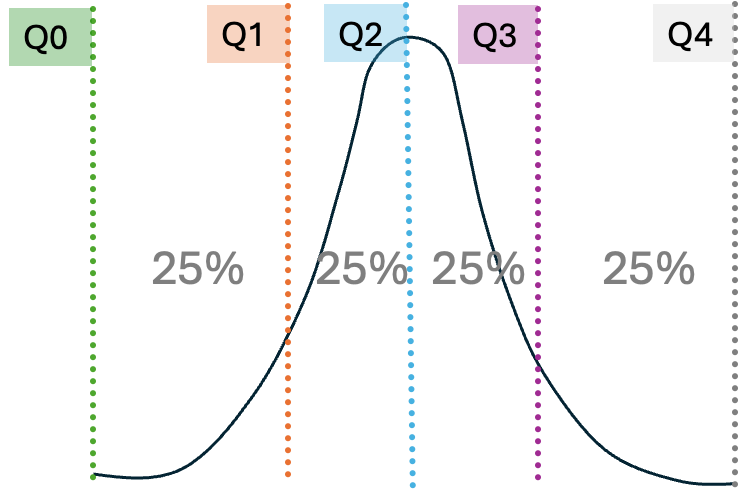

### **Нулевой квартиль Q0 (минимум)** `.min()`/`.quantile(0)`


- значение больше которого 100% данных
- минимум


In [ ]:
df['Age'].min()

0.42

In [ ]:
df['Age'].quantile(0)

0.42

- Возраст самого маленького пассажира на Титанике 5 месяцев (0.42)
- 100% пассажиров старше 5 месяцев

### **Первый квартиль Q1** `.quantile(0.25)`

- 25% наблюдений меньше Q1
- 75% наблюдений больше Q1


In [ ]:
df['Age'].quantile(0.25)

20.125

- 25% пассажиров младше 20 лет
- 75% пассажиров старше 20 лет

### **Второй квартиль Q2 (медиана)** `.median()`/`.quantile(0.5)`

- 50% наблюдений меньше Q2
- 50% наблюдений больше Q2
- медиана


In [ ]:
df['Age'].median()

28.0

In [ ]:
df['Age'].quantile(0.5)

28.0

- 50% пассажиров младше 28 лет
- 50% пассажиров старше 28 лет
- Срединный возраст пассажиров Титаника 28 лет

### **Третий квартиль Q3** `.quantile(0.75)`

- 75% наблюдений меньше Q3
- 25% наблюдений больше Q3


In [ ]:
df['Age'].quantile(0.75)

38.0

- 75% пассажиров младше 38 лет
- 25% пассажиров старше 38 лет

### **Четвертый квартиль Q4 (максимум)** `.max()`/`.quantile(1)`


- значение меньше которого 100% данных
- максимум

In [ ]:
df['Age'].max()

80.0

In [ ]:
df['Age'].quantile(1)

80.0

- Возраст самого взрослого пассажира на Титанике 80 лет
- 100% пассажиров младше 80 лет

## **Меры разброса (вариативности)**

**Меры вариативности (разброса)** - это оценка того, насколько данные разбросаны относительно меры центральной тенденции

### Размах

**Размах** — это разница между самым большим и самым маленьким значением переменной

- Не устойчив к экстремальным значениям (выбросам)

In [ ]:
df['Age'].max() - df['Age'].min()

79.58

Амплитуда изменения возраста в данных равна 79.58

ПРИМЕР:

Выборка: 1 2 3 4 5

1. Минимум равен 1
2. Максимум равен 5
3. Размах 5-1=4

ПРИМЕР:

Выборка: 1 2 3 4 5 100

1. Минимум равен 1
2. Максимум равен 100
3. Размах 100-1=99

### Интерквартильный размах

**Интерквартильный размах** — интервал значений признака, содержащий центральные 50% наблюдений распределения, то есть интервал между первым и третьим квартилем

IQR =Q3-Q1

- Устойчив к экстремальным значениям (выбросам)

In [ ]:
df['Age'].quantile(0.75)-df['Age'].quantile(0.25)

17.875

50% наблюдений (между первым и третим квартилем) по признаку возраст находятся в диапазоне 17.875 лет

### Дисперсия `.var()`

**Дисперсия** — среднее квадратов отклонений от среднего арифметического распределения

- Не устойчив к экстремальным значениям (выбросам)

In [ ]:
df["Age"].var()

211.01912474630802

Средний квадрат отклонения от среднего возраста составялает 211 лет^2

### Среднеквадратичное отклонение `.std()`

**Среднеквадратичное отклонение** (стандартное отклонение) — квадратный корень дисперсии. Мера, которая определяет среднее отклонение от среднего арифметического распределения

- Не устойчив к экстремальным значениям (выбросам)

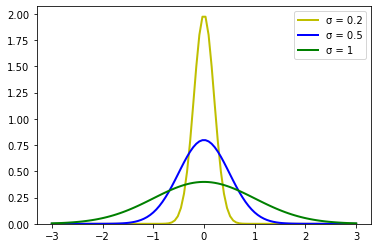

Стандартное отклонение для выборки:

In [ ]:
df["Age"].std()

14.526497332334042

В среднем возраст пассажиров Титаника отклоняется от среднего возраста на 14.5 лет

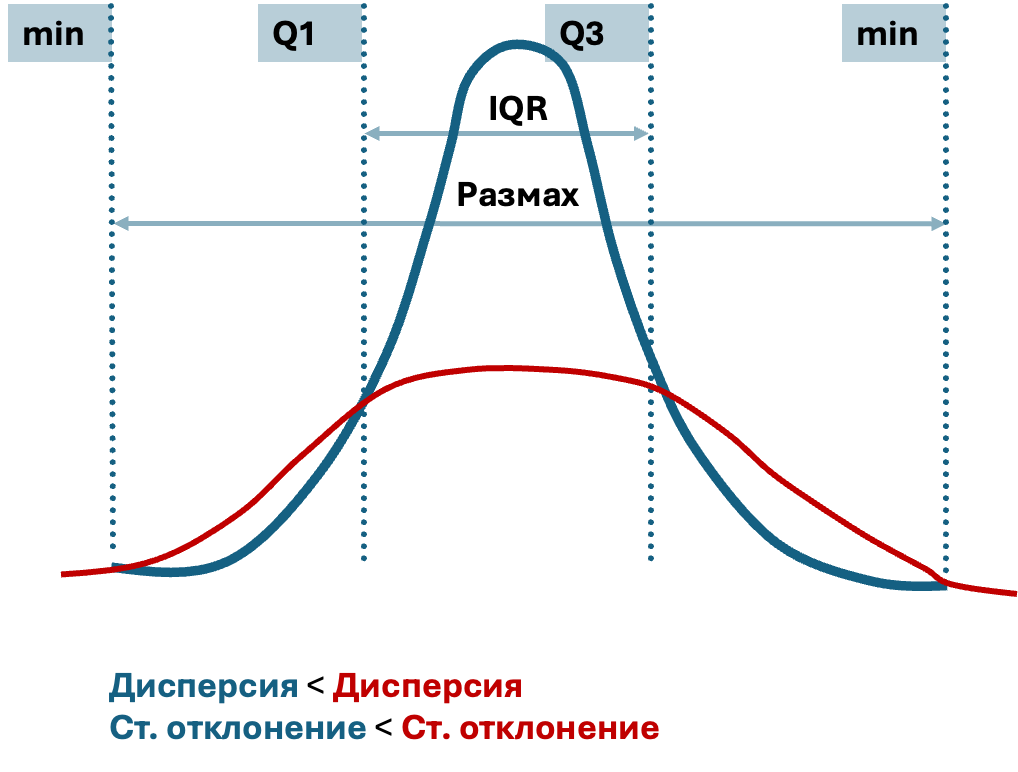

## **Распределение данных**

### Симметричные распределения

+ **Мода** пик(и) распаспределение
+ **Медиана** = **среднее арифметическое** и находятся по середине
+ В данных нет экстремальных значений

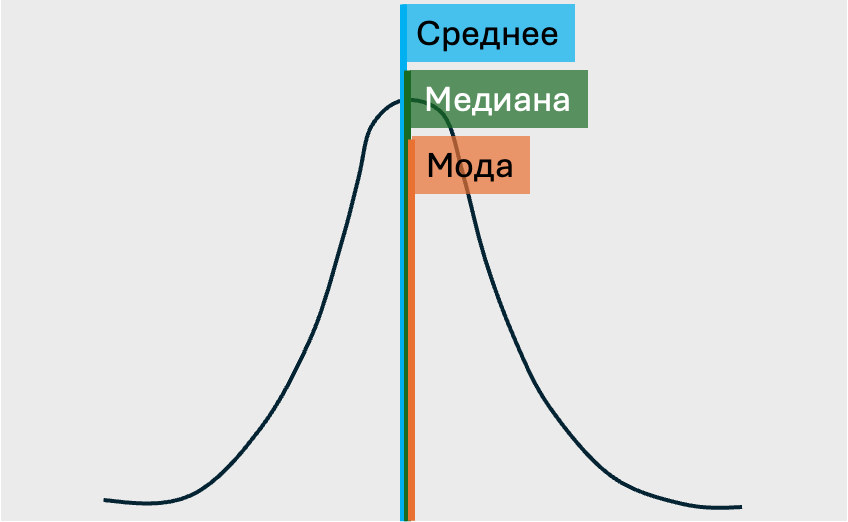

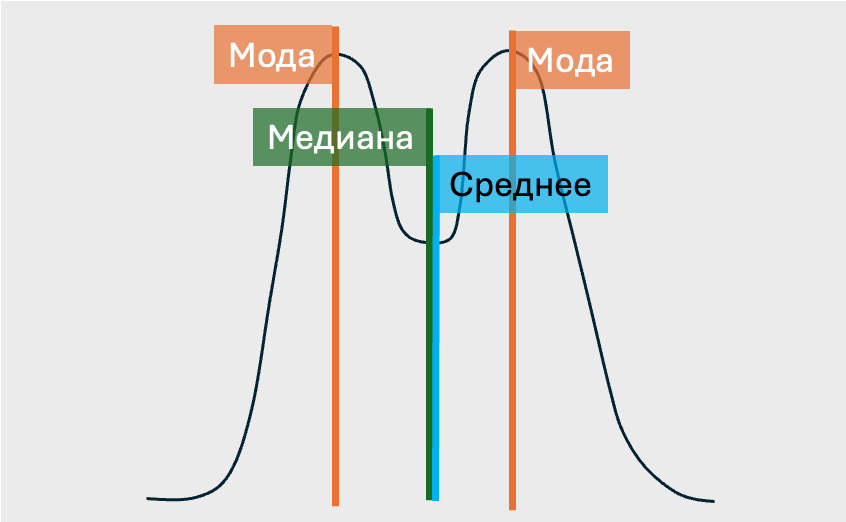

### Несимметричные распределения

+ **Мода** пик(и) расппределения
+ **Среднеe арифметическоe** < **медины**, среднее левее медианы
+ В данных есть экстремально **низкие** значения

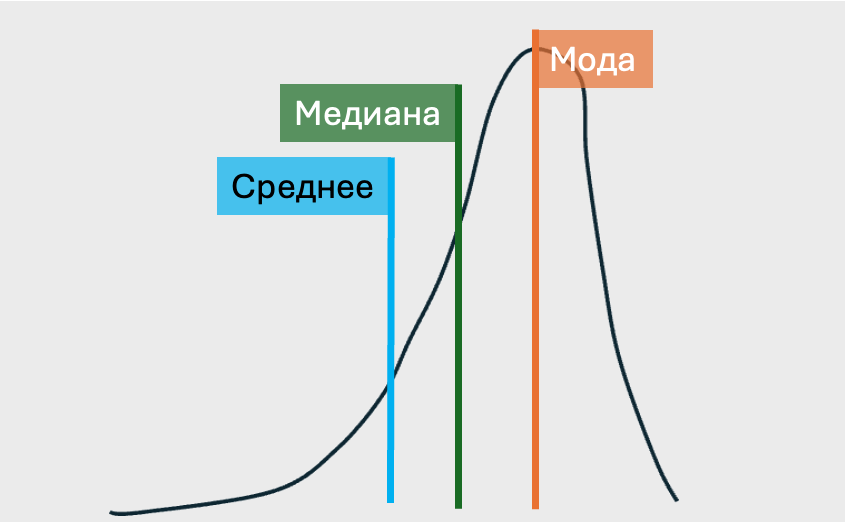

**ПРИМЕР**

**Выборка 1**: 1 2 3 4

Среднее = (1+2+3+4)/4 = 2.5

Медиана = (2+3)/2 = 2.5


**Выборка 2**: -100 1 2 3 4

Среднее = (1+2+3+4-100)/4 = -22.5

Медиана = 2

+ **Мода** пик(и) расппределения
+ **Среднеe арифметическоe** > **медины**, среднее правее медианы
+ В данных есть экстремально **высокие** значения

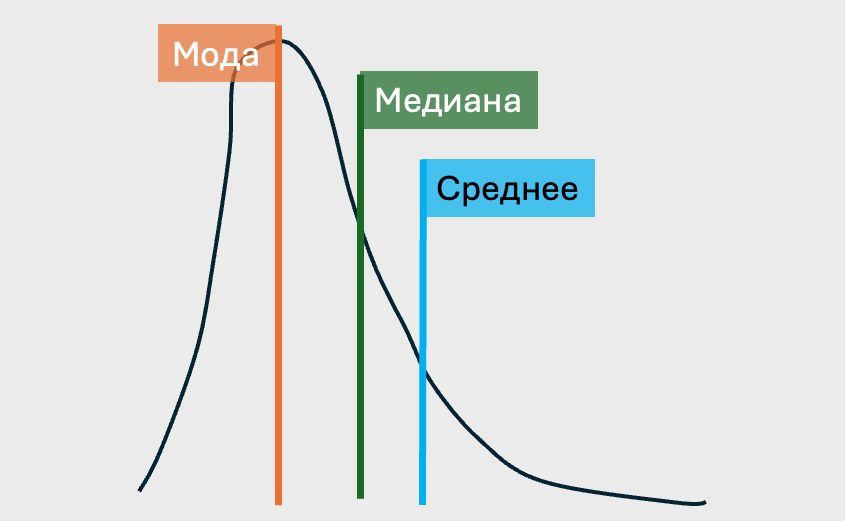

**ПРИМЕР**

**Выборка 1**: 1 2 3 4

Среднее = (1+2+3+4)/4 = 2.5

Медиана = (2+3)/2 = 2.5


**Выборка 2**: 1 2 3 4 100

Среднее = (1+2+3+4+100)/4 = 27.5

Медиана = 3

## A9

На рисунке изображена оценка функции плотности некоторой переменной. Цветными линиями обозначены выборочные медиана, среднее и мода распределения этой переменной. Соотнесите линию и меру центральной тенденции, которую она показывает.

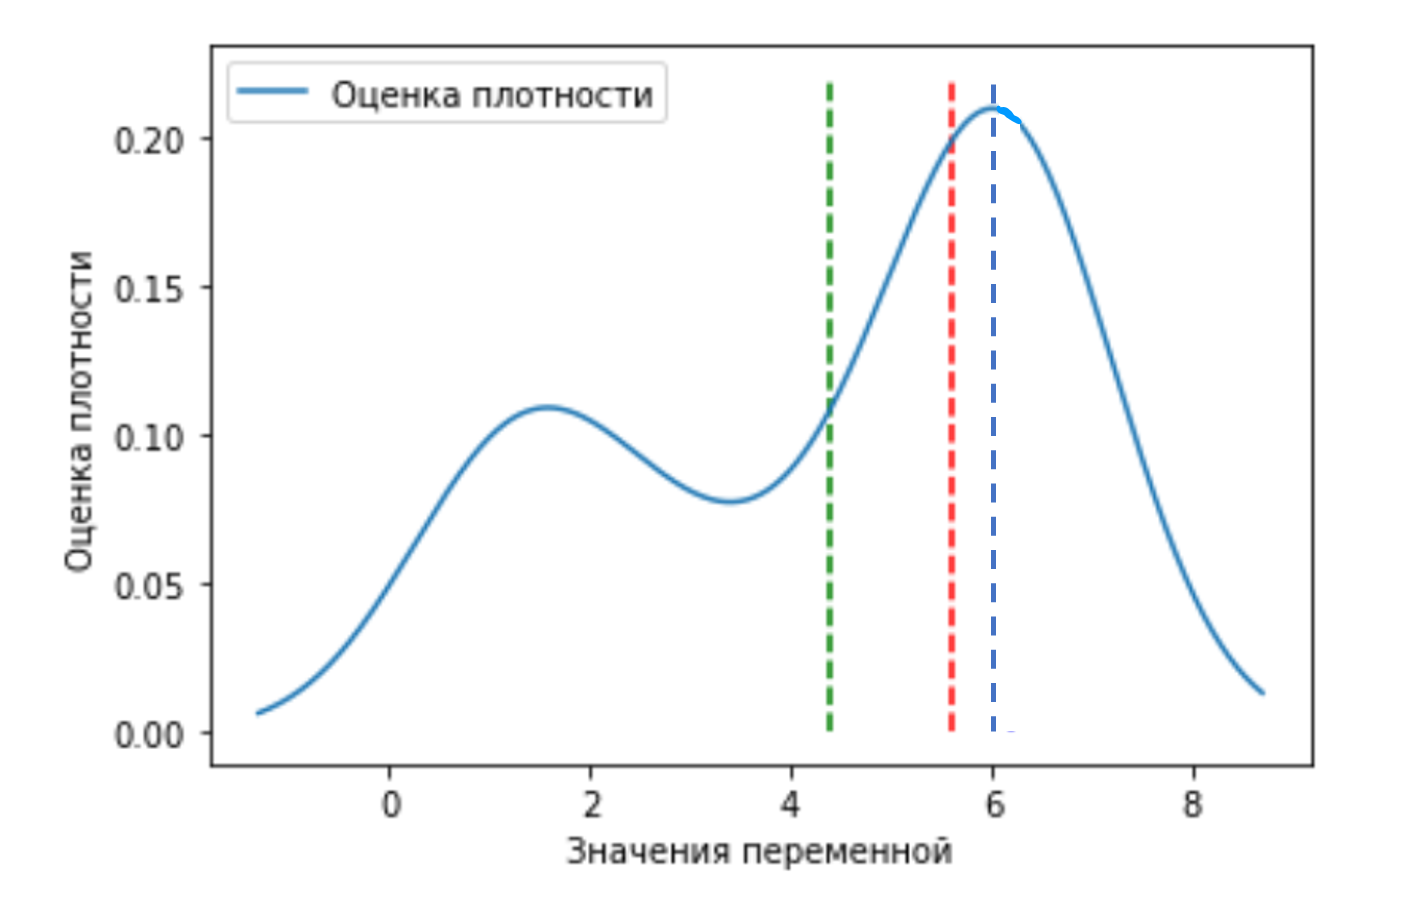

## **Распределение данных в нормальном распределении**

$$ X \sim N(\mu, \sigma^2) $$

+ **Медиана** и **среднее арифметическое, мода** **равны** или почти равны

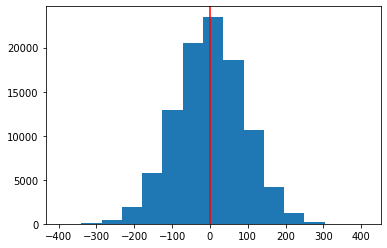

Свойство нормального распределения:

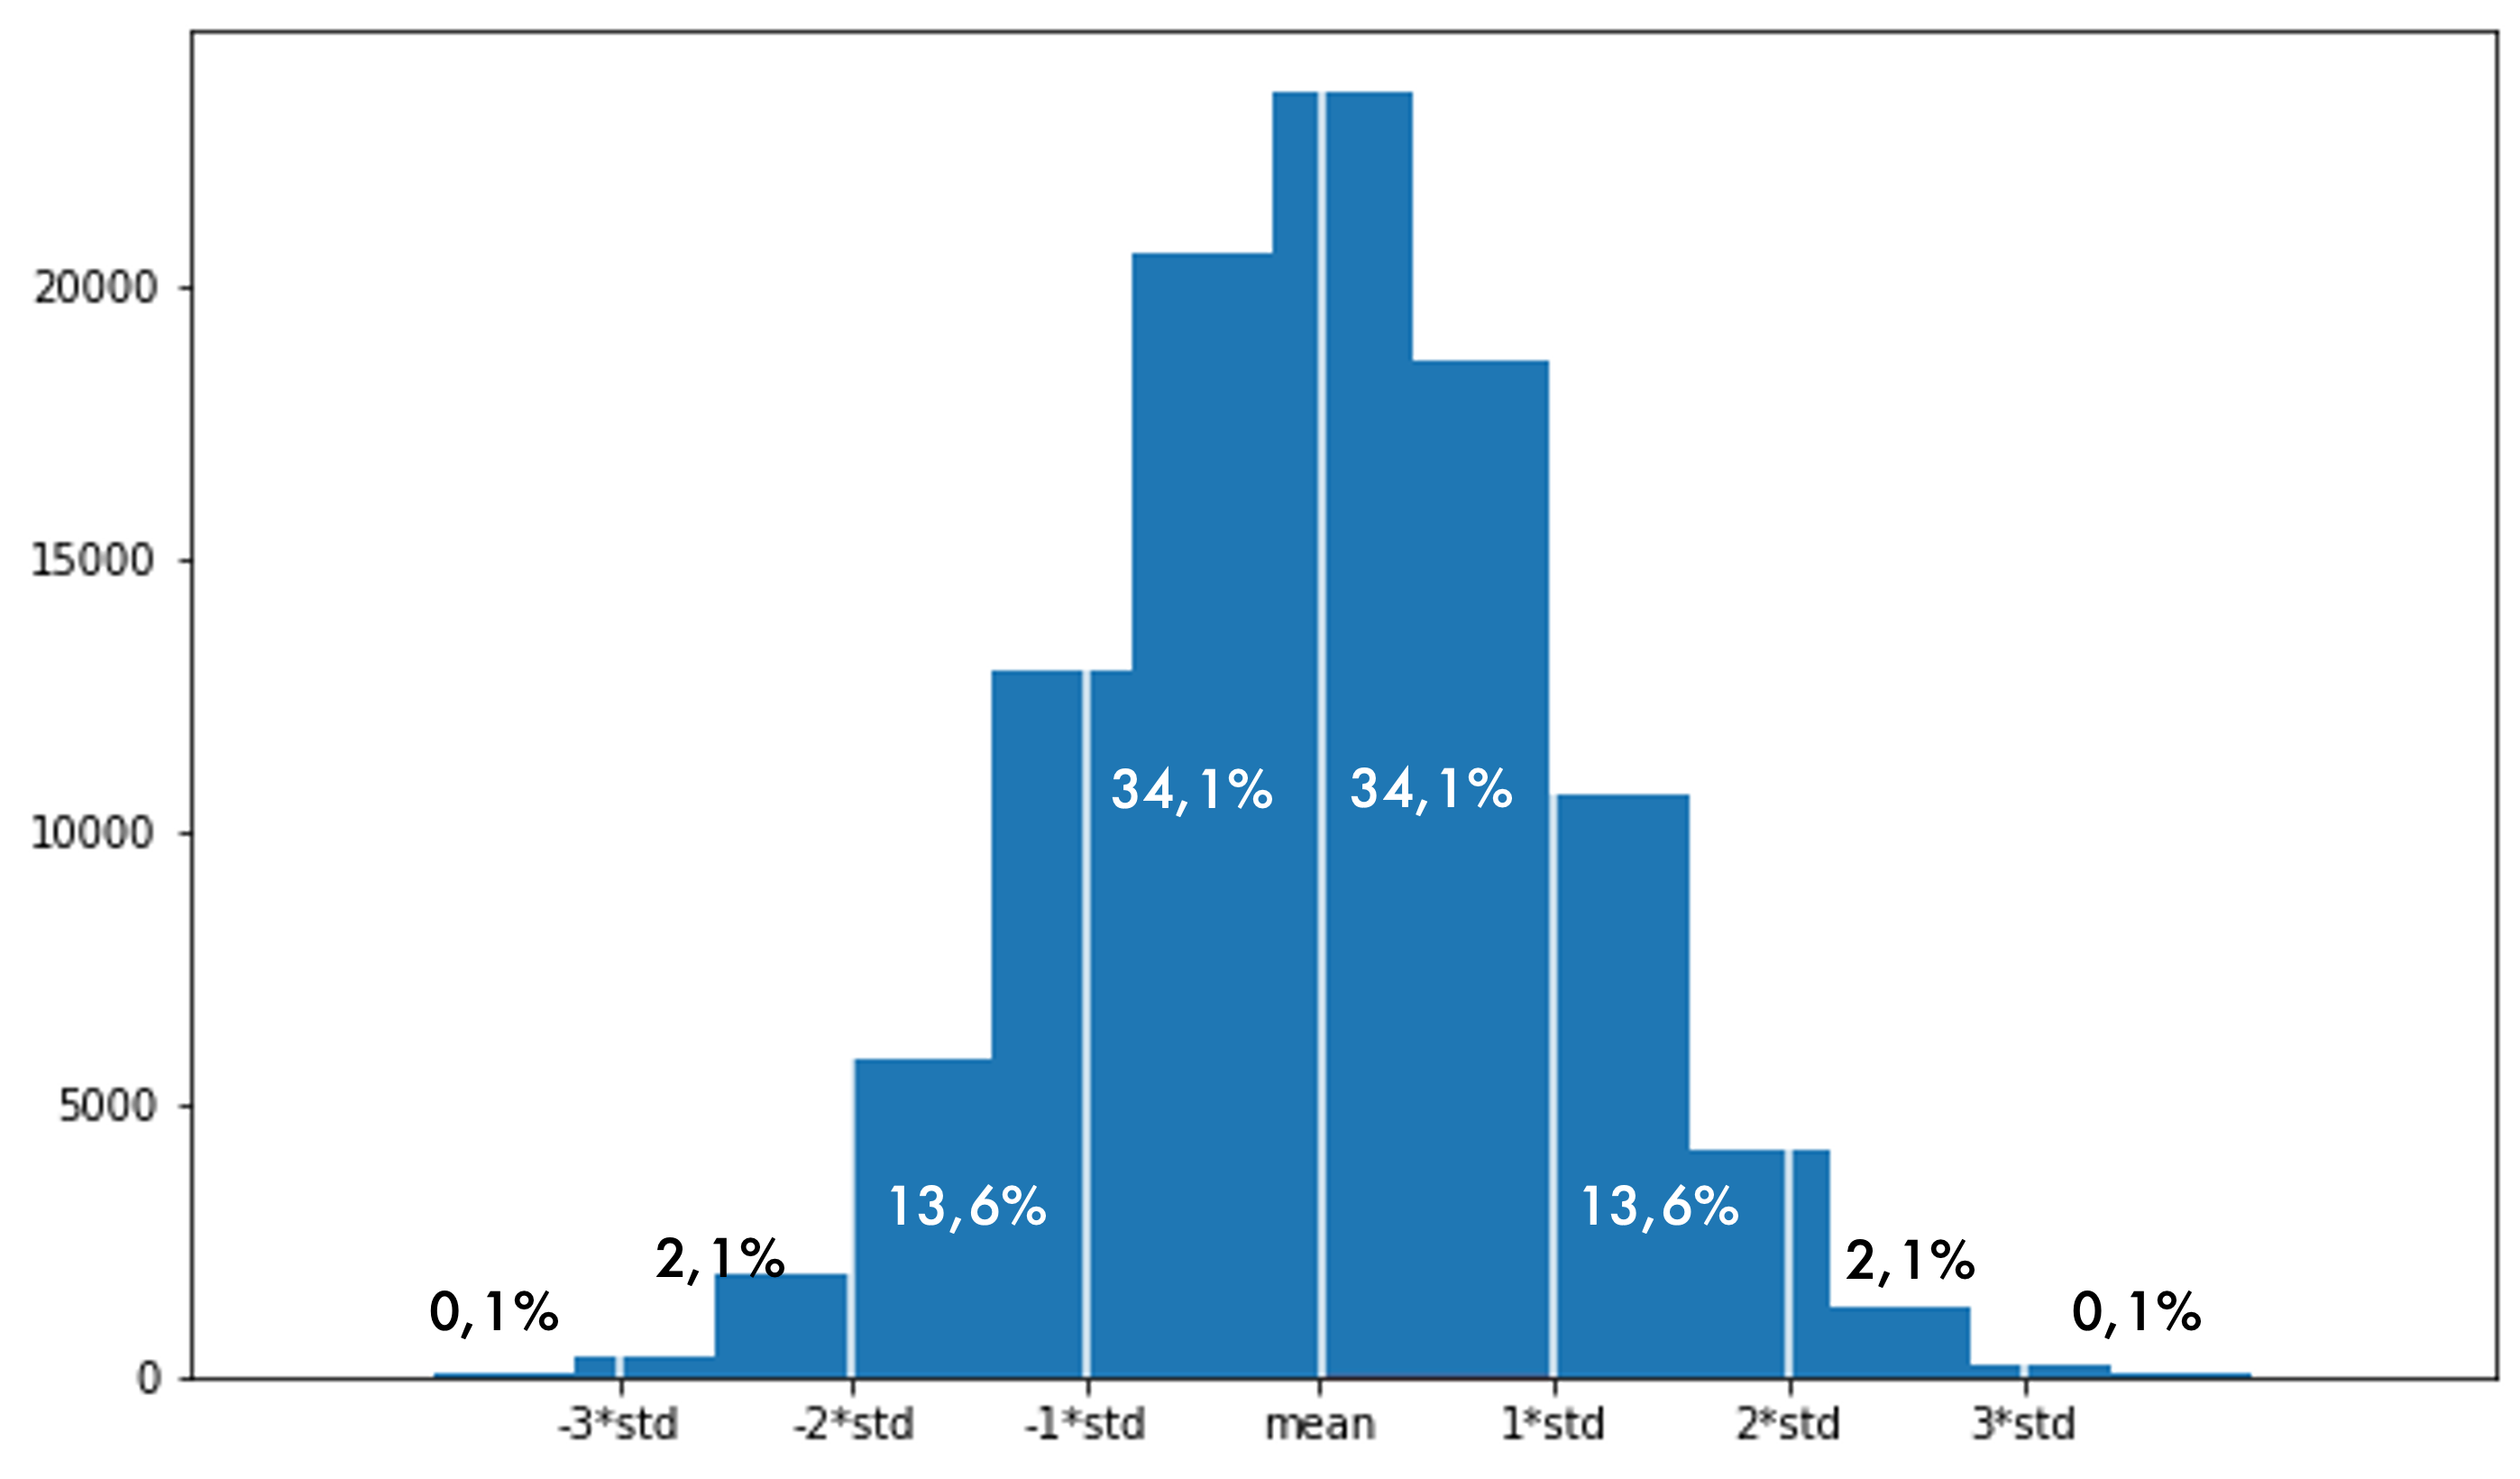

## A4

Предположим, что рост взрослой собаки породы американская акита является нормальной случайной величиной со средним 65 см и стандартным отклонением 2 см. Плотность распределения этой случайной величины изображена на рисунке ниже. Выберите все верные утверждения.

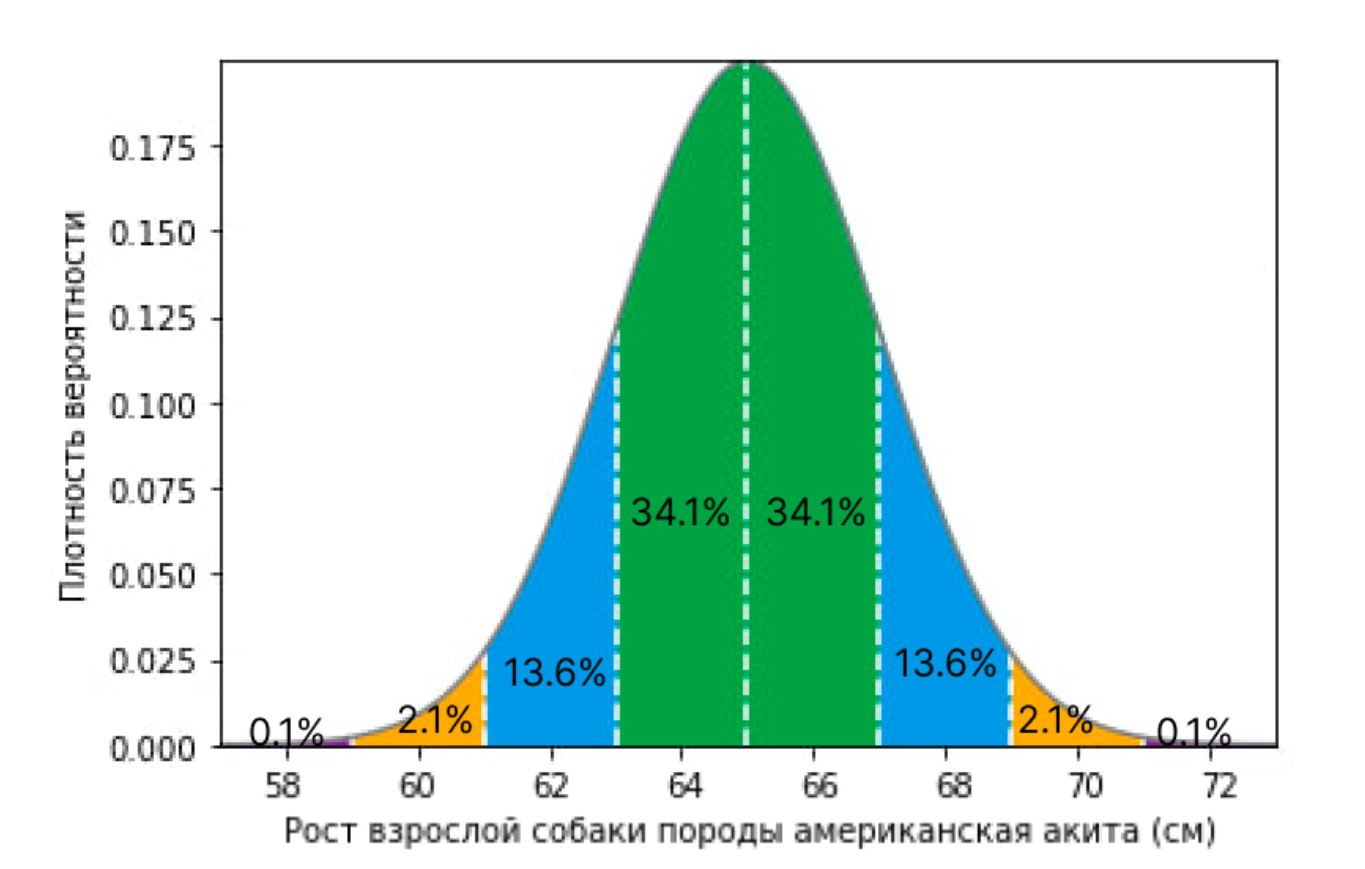

Выберите один или несколько ответов:

+ Почти треть всех взрослых собак породы американская акита имеет рост выше 66 см.


+ Обязательно найдётся взрослая собака породы американская акита с ростом 65 см в случайной выборке из 5 собак той же породы.


+ Около 24% всех взрослых собак породы американская акита имеют рост от 66 до 68 см.


+ 0.1% всех взрослых собак породы американская акита имеет рост не менее 71 см.

65 - 3*2 = 59

65 - 2*2 = 61

65-2 = 63

65

65+2 = 67

65 + 2*2 = 69

65 + 3*2 = 71

## **Пропущенные значения**

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.isna().mean()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
Sex
0
1
1
1
1
0

0.75

-  Если в колонке пропусков больше чем 40%:
 -   **колонку удаляем**

-  Если в колонке пропущено меньше чем 40% данных:
 - **удаляем** все **строчки**, в которых есть пропуски (когда данных много)
 - **заменяем** все **строчки**, в которых есть пропуски (когда данных не очень много)

### Просмотр пропусков

In [ ]:
df[df['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


Если нужно все кроме пропусков, то тогда так:

In [ ]:
df[df['Age'].isna()==False]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Удаление колонки

Удаление колонки:



``` python
датафрейм.drop('название колонки', axis=1) #просто покажет датасет без этой колонки (можно сохранить в новую переменную)
```

``` python
датафрейм.drop('название колонки', axis=1, inplace=True) #правда удалит колонку из изначального датафрейма
```

In [ ]:
df2 = df.drop('Cabin', axis = 1)
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
df.drop('Cabin', axis = 1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
df.drop(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Удаление колонок:



``` python
датафрейм.drop(['название колонки 1', 'название колонки 2'], axis=1) #просто покажет датасет без этой колонки (можно сохранить в новую переменную)
```

In [ ]:
df.drop(['Age', 'Cabin'], axis=1)

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,30.0000,C


### Удаление строк с пропусками

##### **Удаление**

Удаляем все строчки, хотя бы с одним пропуском



``` python
датафрейм.dropna(subset = ['название колонки'], axis=1) #просто покажет датасет без nan (можно сохранить в новую переменную)
```

``` python
датафрейм.dropna(subset = ['название колонки'], inplace=True) #правда удалит nan из изначального датафрейма
```

In [ ]:
df4 = df.dropna()
df4

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


Удаляем все строчки, в которых есть пропуски в определенной колонке

In [ ]:
df4 = df.dropna(subset = 'Age')
df4.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Замена пропусков в столбце

Можно заменить пропуск данных на:
- меру центральной тенденции по всему столбцу
- меру центральной тенденции внутри группы
- на случайный элемент

#### На МЦТ по всему столбцу

**Количественные данные**:
-  **медиану**/среднее

**Категориальные данные**:
 -  заменяем на моду

Количественная:

In [ ]:
med = df['Age'].median()
df['Age_fillna'] = df['Age'].fillna(med) #заменяем все пропуски в столбце возраст на Медиану

Проверяем, что все пропуски заменились

In [ ]:
df[df['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_fillna
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,28.0
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,28.0
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,28.0
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,28.0
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,28.0
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,28.0
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,28.0
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,28.0


In [ ]:
df[df['Age'].isna()==False]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_fillna
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,39.0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0


Пример с категориальной:

In [ ]:
df['Embarked'].mode()[0]

'S'

In [ ]:
mode = df['Embarked'].mode()[0]
df['Embarked_fillna'] = df['Embarked'].fillna(mode) #заменяем все пропуски в столбце порт на моду
df[df['Embarked'].isna()] #проверяем, что замена случилась

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_fillna
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,S
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,S


#### На МЦТ по группе

In [ ]:
df.groupby('Pclass')['Age'].median()

,Age
Pclass,
1,37.0
2,29.0
3,24.0


С помощью метода `.transform()` подставляем каждому пассажиру медианный возраст в зависимости от класса

In [ ]:
gb = df.groupby('Pclass')['Age'].transform('median')
gb

,Age
0,24.0
1,37.0
2,24.0
3,37.0
4,24.0
...,...
886,29.0
887,37.0
888,24.0
889,37.0


4. Заменим возраст на медиану внутри одного класса (Pclass) только для пропущенных с помощью метода `.fillna()`

In [ ]:
df['Age_fillna_mg'] = df['Age'].fillna(gb)

5. Проверим, что получилось

In [ ]:
df[df.Age.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_fillna,Embarked_fillna,Age_fillna_mg
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,28.0,Q,24.0
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,28.0,S,29.0
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,28.0,C,24.0
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,28.0,C,24.0
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,28.0,Q,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,28.0,C,24.0
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,28.0,S,24.0
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,28.0,S,24.0
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,28.0,S,24.0


## **Выбросы**

**Выброс** — это аномальное значение в данных, которое значительно отличается от значения, выраженного мерой центральной тенденции и в целом от распределения данных в выборке



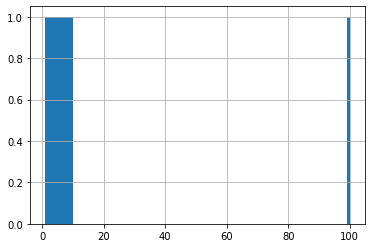

In [ ]:
pd.Series([1,2,3,4,5,6,7,8,9,100]).hist(bins=100)

Два способа найти выбросы:
- IQR*1.5
- N *std

### N*std

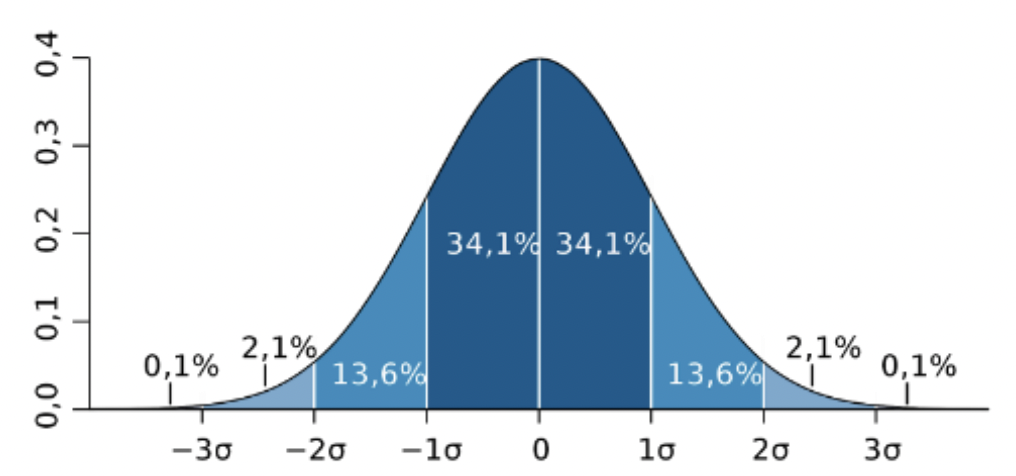

Если распределение данных нормальное:

- если брать **1 стандартное отклонение** от среднего, то НЕ выбросами будут считаться **68,2%** центральных данных

- если брать **2 стандартных отклонения** от среднего, то НЕ выбросами будут считаться **95,5%** центральных данных

- если брать **3 стандартных отклонения** от среднего, то НЕ выбросами будут считаться **99,7%** центральных данных (а выбросами соответственно 0,2-0,3%)

$$ (avg - N*std; avg + N*std) $$

In [ ]:
avg = df['Age_fillna'].mean()
std = df['Age_fillna'].std()
low2 = avg-3*std
up2 = avg+3*std
low2, up2

(-9.697507161337093, 68.42067214450208)

3. Сделаем фильтрацию и посчитаем те значения, которые являются выбросами

In [ ]:
df[(df['Age_fillna']<low2) | (df['Age_fillna']>up2)].shape[0]

7

4. Или те, которые считаются выбросами:

In [ ]:
df_clean = df[(df['Age_fillna']>=low2) & (df['Age_fillna']<=up2)]
df_clean#.shape[0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_fillna
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,28.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0


Дастасет без выбросомв можно сохранить в новую переменную и дальше работать с ним:

### 1.5*IQR

1. Находим интерквартильное расстояние

In [ ]:
q1=df['Age_fillna'].quantile(0.25)
q1

22.0

In [ ]:
q3=df['Age_fillna'].quantile(0.75)
q3

35.0

In [ ]:
iqr = q3-q1
iqr

13.0

$$(q1 - 1.5*IQR; q3 +1.5*IQR) $$

2. Находим границы интервала, все значения за пределами которого буду считаться выбросами

In [ ]:
low1 = q1 - iqr*1.5 #нижняя границы
low1

2.5

In [ ]:
up1 = q3 + iqr*1.5 #верхняя граница
up1

54.5

3. Сделаем фильтрацию и посчитаем те значения, которые являются выбросами

In [ ]:
df[(df['Age_fillna']<low1) | (df['Age_fillna']>up1)].shape[0]

66

4. А теперь посмотрим на распределение данных без учета выбросов

In [ ]:
df_clean = df[(df['Age_fillna']>=low1) & (df['Age_fillna']<=up1)]
df_clean

825

## **Ящик с усами** `.plot(kind = 'box', vert = False)`

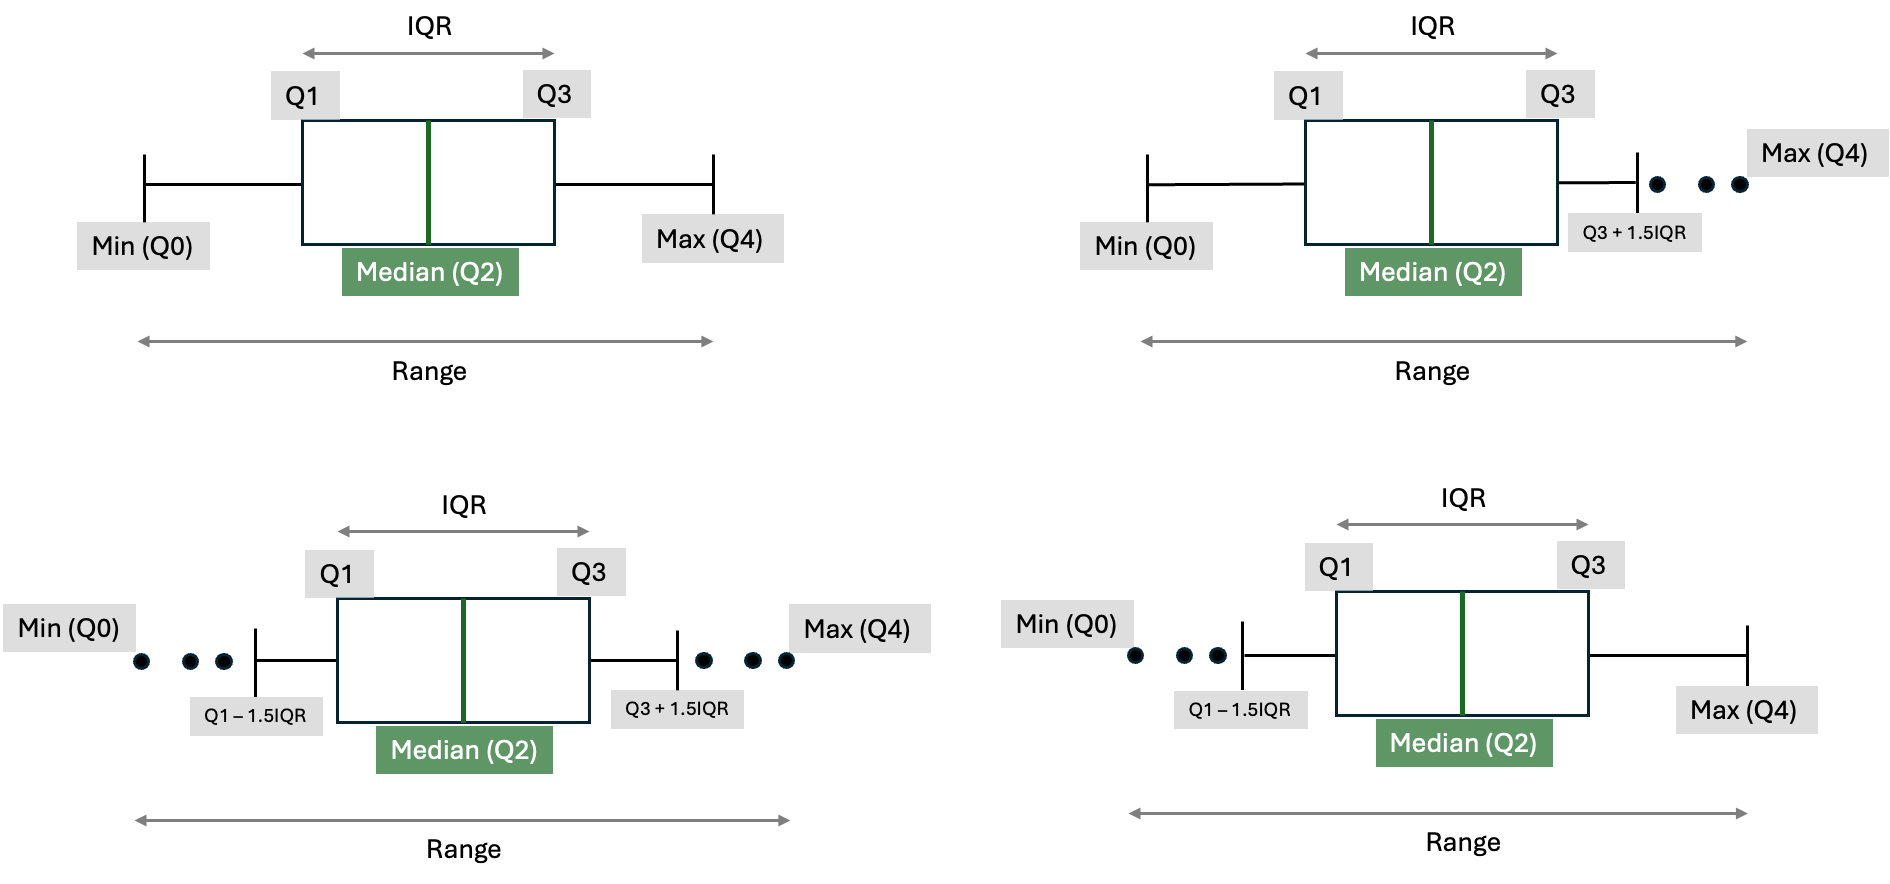

<Axes: >

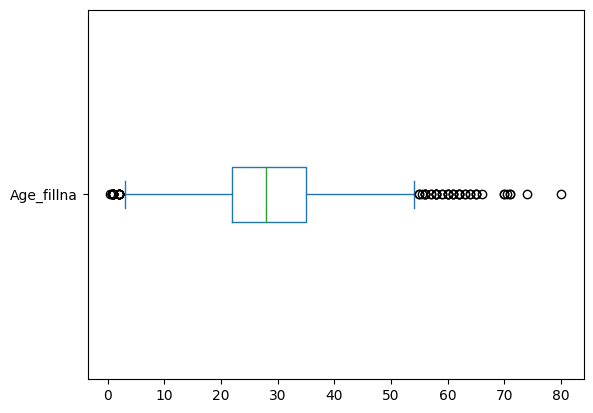

In [ ]:
df['Age_fillna'].plot(kind = 'box', vert = False) #vert = False, чтобы ящик был горизонтальный